In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

c:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# import os
# os.listdir('/kaggle/input/')
# train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
# test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
# 数据加载
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

test_data_copy = test_data.copy()
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 预处理1st: 自己判断
def pre1(df):
    df = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin'])  # 删去了0、3、8、9、10（0、3、8是序列关系, 9是被包含了, 10是太少了）
    df['Companion'] = df['SibSp'] + df['Parch']
    df = df.drop(columns = ['SibSp', 'Parch'])  # 合并6和7

    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df

train_data = pre1(train_data)
test_data = pre1(test_data)

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Sex        891 non-null    object 
 3   Age        891 non-null    float64
 4   Embarked   891 non-null    object 
 5   Companion  891 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


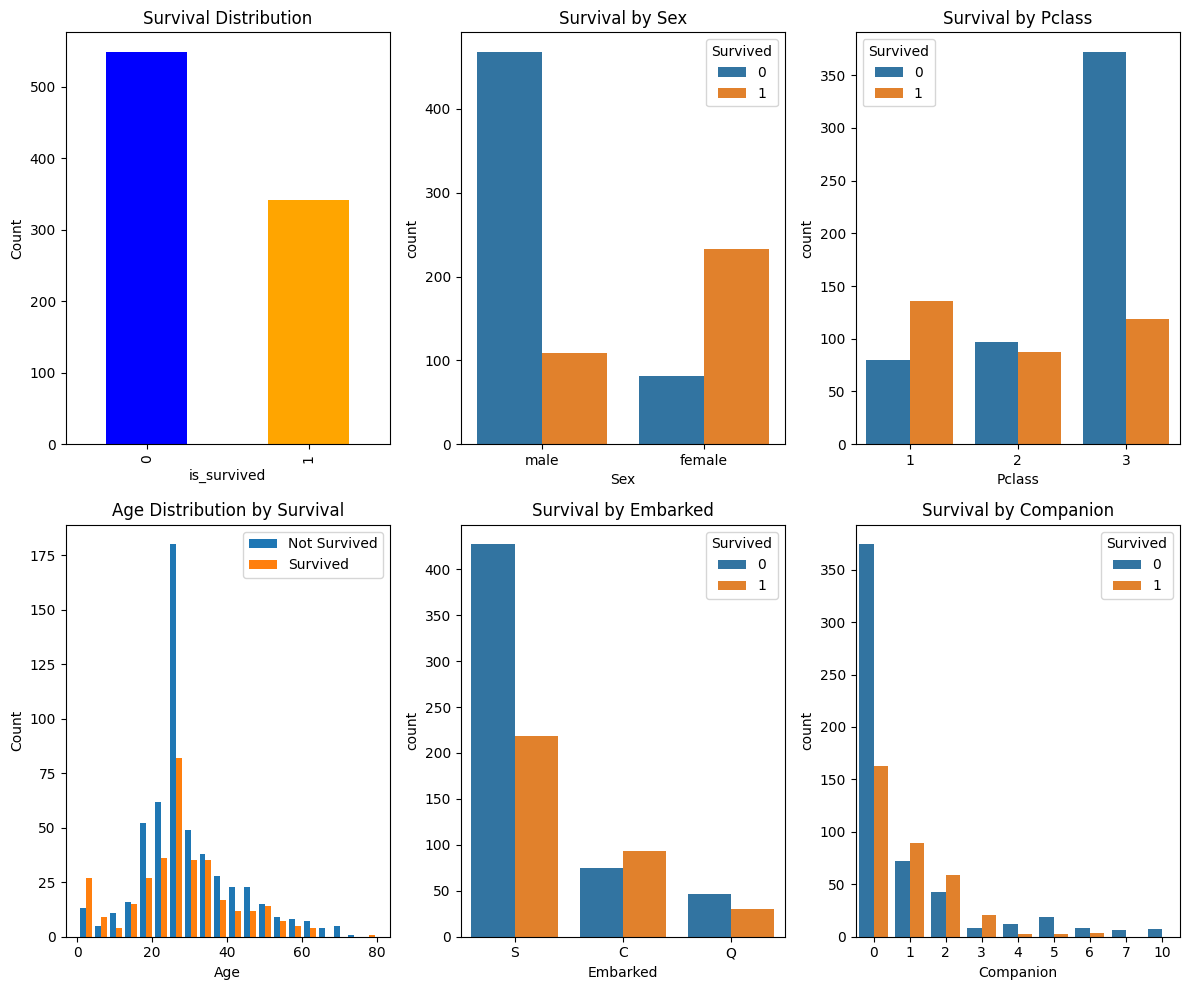

In [6]:
# 预处理2nd: 可视化
plt.figure(figsize = (12, 10))

# y自身
plt.subplot(2, 3, 1)
colors = ['blue', 'orange']
train_data['Survived'].value_counts().plot(kind='bar', color=colors)
plt.title('Survival Distribution')
plt.xlabel('is_survived')
plt.ylabel('Count')

# 特征1: 性别
plt.subplot(2, 3, 3)
sns.countplot(train_data, x = 'Pclass', hue = 'Survived')
plt.title('Survival by Pclass')

# 特征2: 客舱等级
plt.subplot(2, 3, 2)
sns.countplot(train_data, x = 'Sex', hue = 'Survived')
plt.title('Survival by Sex')

# 特征3: 年龄
plt.subplot(2, 3, 4)
plt.hist([train_data[train_data['Survived'] == 0]['Age'], 
          train_data[train_data['Survived'] == 1]['Age']], 
         bins=20, label=['Not Survived', 'Survived'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.title('Age Distribution by Survival')

# 特征4: 登船港口
plt.subplot(2, 3, 5)
sns.countplot(train_data, x = 'Embarked', hue = 'Survived')
plt.title('Survival by Embarked')

# 特征5: 同伴规模
plt.subplot(2, 3, 6)
sns.countplot(train_data, x = 'Companion', hue = 'Survived')
plt.title('Survival by Companion')

plt.tight_layout()
plt.show()

In [7]:
# 预处理3rd: 特征工程
def pre3(df):
    # 处理特征1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # 处理特征3
    df = df.rename(columns = {'Age': 'Age_Tem'})
    df['Age'] = pd.cut(df['Age_Tem'], 
                    bins=[0, 8, 18, 48, 100], 
                    labels=['Child', 'Teen', 'Adult', 'Elderly'])
    df = df.drop(columns = ['Age_Tem'])
    df = pd.get_dummies(df, columns = ['Age'])

    # 处理特征4
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 1})

    # 处理特征5
    df = df.rename(columns = {'Companion': 'Companion_Tem'})
    df['Companion'] = pd.cut(df['Companion_Tem'], 
                        bins=[0, 0.5, 3, 10], 
                        labels=['Single', 'Small', 'Large'])  
    df = df.drop(columns = ['Companion_Tem'])
    df = pd.get_dummies(df, columns = ['Companion'])

    return df

train_data = pre3(train_data)
test_data = pre3(test_data)

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Survived          891 non-null    int64
 1   Pclass            891 non-null    int64
 2   Sex               891 non-null    int64
 3   Embarked          891 non-null    int64
 4   Age_Child         891 non-null    bool 
 5   Age_Teen          891 non-null    bool 
 6   Age_Adult         891 non-null    bool 
 7   Age_Elderly       891 non-null    bool 
 8   Companion_Single  891 non-null    bool 
 9   Companion_Small   891 non-null    bool 
 10  Companion_Large   891 non-null    bool 
dtypes: bool(7), int64(4)
memory usage: 34.1 KB


In [8]:
# 开始训练
X = train_data.drop(columns = ['Survived'])
y = train_data['Survived']
X_test = test_data

X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Pclass            418 non-null    int64
 1   Sex               418 non-null    int64
 2   Embarked          418 non-null    int64
 3   Age_Child         418 non-null    bool 
 4   Age_Teen          418 non-null    bool 
 5   Age_Adult         418 non-null    bool 
 6   Age_Elderly       418 non-null    bool 
 7   Companion_Single  418 non-null    bool 
 8   Companion_Small   418 non-null    bool 
 9   Companion_Large   418 non-null    bool 
dtypes: bool(7), int64(3)
memory usage: 12.8 KB


In [9]:
# 划分测试集和验证集
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size = 0.2
)

In [10]:
# 模型群
from sklearn.dummy import DummyClassifier # 基准模型
from sklearn.linear_model import LogisticRegression   # 逻辑回归
from sklearn.svm import SVC  # 支持向量机
from sklearn.neighbors import KNeighborsClassifier  # K邻近
from sklearn.naive_bayes import GaussianNB   # 高斯朴素贝叶斯
from sklearn.tree import DecisionTreeClassifier  # 决策树

models = {
    'm0_dummy': DummyClassifier(),
    'm1_logist': LogisticRegression(),
    'm2_svc': SVC(),
    'm3_knn': KNeighborsClassifier(),
    'm4_bayes': GaussianNB(),
    'm5_tree': DecisionTreeClassifier()
}

In [11]:
# 模型评价
from sklearn.metrics import accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    accuracy = accuracy_score(y_valid, y_pred)
    print(f"{name}模型的准确率为: {accuracy:.4f}")

m0_dummy模型的准确率为: 0.6369
m1_logist模型的准确率为: 0.8101
m2_svc模型的准确率为: 0.8212
m3_knn模型的准确率为: 0.8380
m4_bayes模型的准确率为: 0.7821
m5_tree模型的准确率为: 0.8268


In [12]:
# 挑选模型（先排除m3和m4）
from sklearn.model_selection import GridSearchCV

# m1_logist
logist_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],   #  正则化方式 
    'max_iter': [1000, 2000],
    'solver': ['saga', 'liblinear']
}

logist_search = GridSearchCV(
    LogisticRegression(),
    logist_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,         # 使用所有CPU 
    verbose = 0
)

logist_search.fit(X_train, y_train)
print(f"m1_logist模型最佳参数:", logist_search.best_params_)
print(f"m1_logist模型最好分数:", logist_search.best_score_)

# m2_svc
svc_grid = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'sigmoid'],   # 核函数类型
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]   # 核参数
}

svc_search = GridSearchCV(
    SVC(),
    svc_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 0
)

svc_search.fit(X_train, y_train)
print(f"m2_svc模型最佳参数:", svc_search.best_params_)
print(f"m2_svc模型最好分数:", svc_search.best_score_)

# m5_tree
tree_grid = {
    'max_depth': [2, 3, 5, 7, 11],   # 树深度
    'max_features': ['sqrt', 'log2']   # 寻找最佳分割时考虑的特征数量
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(),
    tree_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 0
)  

tree_search.fit(X_train, y_train)
print(f"m3_tree模型最佳参数:", tree_search.best_params_)
print(f"m3_tree模型最好分数:", tree_search.best_score_)

m1_logist模型最佳参数: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
m1_logist模型最好分数: 0.8187826258248793
m2_svc模型最佳参数: {'C': 0.01, 'gamma': 1, 'kernel': 'poly'}
m2_svc模型最好分数: 0.8286220821432091
m3_tree模型最佳参数: {'max_depth': 5, 'max_features': 'sqrt'}
m3_tree模型最好分数: 0.8258051807347583


In [13]:
# 提交
y_pred2 = SVC(C = 0.01, gamma = 1, kernel = 'poly').fit(X, y).predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_data_copy['PassengerId'],
    'Survived': y_pred2
})

submission.to_csv('submission.csv', index = False)
print(submission)

     PassengerId  Survived
0            892         0
1            893         1
2            894         0
3            895         0
4            896         1
..           ...       ...
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         0

[418 rows x 2 columns]
